In [2]:
import numpy as np
import sklearn
%matplotlib inline
import matplotlib as mpl 
import matplotlib.pyplot as plt

The following commands are the same as for the Boosted Decision Tree file. They are used to extract the information from the dataset and to divide it into the necessary groups for training, validation and testing. 

In [3]:
import pandas as pd

df = pd.read_csv('HIGGS.csv.gz', header=None, nrows=500_000)

In [4]:
y = df.iloc[:, 0].values 
X = df.iloc[:, 1:].values

In [ ]:
from sklearn.model_selection import train_test_split

X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

The first attempt to test the Deep Neural Network algorithms consists of a simple model with two layers, five epochs, and a 40% validation split. Below, "Sequential" defines the neural network as a sequence of steps; the "shape" parameter defines the structure of the array given in input, so, in this case, 28 features; while every layer is characterised by a number of neurons and by an activation function. The final, output, layer contains a single neuron, whose purpose is to classify each incoming event as either signal or background by producing an output value between 0 and 1. 

In [13]:
from tensorflow.keras import models
from tensorflow.keras import Input, layers
higgs_DNN_0 = models.Sequential([
  Input(shape=(28,)), 
  layers.Dense(128, activation='relu'), 
  layers.Dense(1, activation='sigmoid') 
])

I0000 00:00:1788947808.370651    2022 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788947808.383939    2022 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1788947809.825686    2022 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1788947814.703688    2022 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

In [14]:
higgs_DNN_0.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         3,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,841 (15.00 KB)

 Trainable params: 3,841 (15.00 KB)

 Non-trainable params: 0 (0.00 B)

What follows is the compilation step. The optimizer is the algorithm that decides how to update the weights after each batch of training, "adam" stands for "ADAptive Moment estimation" and is largely used mainly due to two main features: it tracks how much each weight has been changing and adjusts its learning rate accordingly, also remembering the direction of previous updates and using it to smooth the path toward the minimum. The other two terms define the mathematical error that the model tries to minimise while learning, in this case it is "binary_crossentropy" because the algorithm needs to distinguish between two categories: signal and background, while "metrics" allow for the loss and accuracy parameters to be visible in the output when the fit is executed. 

In [15]:
higgs_DNN_0.compile(optimizer='adam', 
                   loss='binary_crossentropy', 
                   metrics=['accuracy']) 

For what concerns the fit process, the required arguments are the number of epochs, representing the number of times the entire training dataset is passed through the neural network; the batch size, indicating how many events the network sees before updating its weights once; and the validation split, which determines the subset of the training dataset that will be kept for internal testing. 

In [16]:
%%time

history_0 = higgs_DNN_0.fit(X_train, y_train, epochs=5, batch_size=128, validation_split=0.4)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.6291 - loss: 0.6400 - val_accuracy: 0.6516 - val_loss: 0.6249
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6588 - loss: 0.6166 - val_accuracy: 0.6723 - val_loss: 0.6057
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.6752 - loss: 0.6020 - val_accuracy: 0.6758 - val_loss: 0.5978
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6818 - loss: 0.5952 - val_accuracy: 0.6811 - val_loss: 0.5922
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.6865 - loss: 0.5896 - val_accuracy: 0.6895 - val_loss: 0.5880
CPU times: user 36 s, sys: 8.64 s, total: 44.7 s
Wall time: 31.1 s


In [17]:
test_loss, test_acc = higgs_DNN_0.evaluate(X_test, y_test)
print('test_acc:', test_acc)

3125/3125 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.6855 - loss: 0.5916
test_acc: 0.6855000257492065


Given the low accuracy on the test set a check that compared both the actual label of the event and its predicted one was performed. As it can be seen below, the model isn't capable of correctly identifying many of the events. 

In [18]:
prob_labels = higgs_DNN_0.predict(X_test, verbose=0)
pred_labels = (prob_labels > 0.5).astype(int)

print("Actual label:     ", y_test[:20])
print("Predicted label:", pred_labels[:20])

Actual label:      [1. 1. 1. 1. 0. 0. 0. 0. 0. 1. 1. 0. 1. 0. 0. 1. 0. 0. 0. 1.]
Predicted label: [[1]
 [0]
 [1]
 [1]
 [0]
 [0]
 [0]
 [1]
 [0]
 [1]
 [1]
 [0]
 [1]
 [1]
 [0]
 [0]
 [1]
 [1]
 [1]
 [1]]


The following plot is generated in order to better visualise the performance of the algorithm. It shows the values of the accuracy and loss on both the training and validation datasets in function of the number of epochs. 

<Axes: >

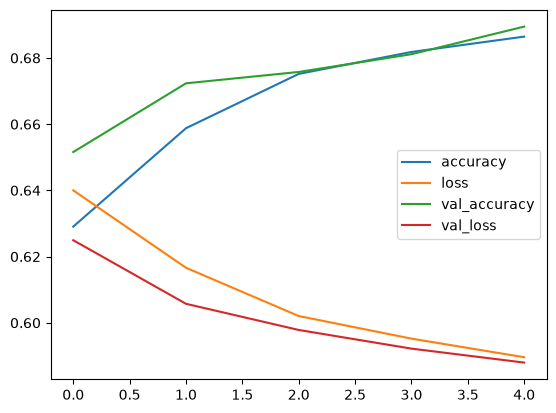

In [19]:
import pandas as pd

pd.DataFrame(history_0.history).plot()

Given the low performances of the model, a new one was developed with an increased number of layers, keeping the other parameters unchanged. 

In [20]:
from tensorflow.keras import models
from tensorflow.keras import Input, layers
higgs_DNN_1 = models.Sequential([ 
  Input(shape=(28,)),  
  layers.Dense(128, activation='relu'), 
  layers.Dense(128, activation='relu'),
  layers.Dense(128, activation='relu'),
  layers.Dense(128, activation='relu'),
  layers.Dense(128, activation='relu'),
  layers.Dense(1, activation='sigmoid')
])

In [21]:
higgs_DNN_1.compile(optimizer='adam', 
                   loss='binary_crossentropy', 
                   metrics=['accuracy']) 

In [22]:
%%time

history_1 = higgs_DNN_1.fit(X_train, y_train, epochs=5, batch_size=128, validation_split=0.4)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.6542 - loss: 0.6164 - val_accuracy: 0.6747 - val_loss: 0.5958
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.6870 - loss: 0.5852 - val_accuracy: 0.6946 - val_loss: 0.5779
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.6987 - loss: 0.5709 - val_accuracy: 0.6965 - val_loss: 0.5724
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7084 - loss: 0.5598 - val_accuracy: 0.7090 - val_loss: 0.5594
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.7147 - loss: 0.5519 - val_accuracy: 0.7144 - val_loss: 0.5536
CPU times: user 1min 4s, sys: 11.3 s, total: 1min 15s
Wall time: 46.7 s


In [23]:
test_loss, test_acc = higgs_DNN_1.evaluate(X_test, y_test)
print('test_acc:', test_acc)

3125/3125 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.7099 - loss: 0.5595
test_acc: 0.7099199891090393


<Axes: >

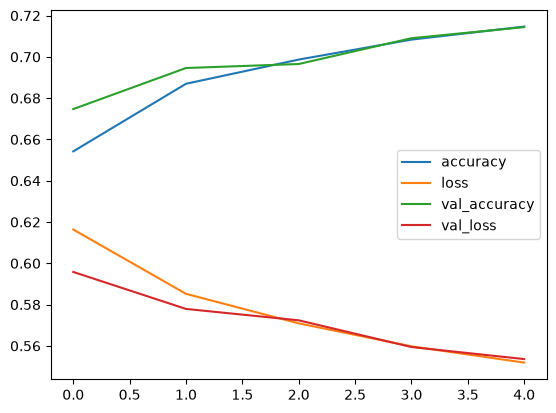

In [24]:
pd.DataFrame(history_1.history).plot()

As visible from the values of the above results, increasing the number of layers didn't lead to a significant improvement in the model performance. 

For this reason, a new algorithm was built. This one kept the number of layers defined in the previous model, but decreased the validation split to the 30%, hoping in this way to allow for a better training of the model on the dataset. 

In [25]:
from tensorflow.keras import models
from tensorflow.keras import Input, layers
higgs_DNN_2 = models.Sequential([
  Input(shape=(28,)),  
  layers.Dense(128, activation='relu'), 
  layers.Dense(128, activation='relu'),
  layers.Dense(128, activation='relu'),
  layers.Dense(128, activation='relu'),
  layers.Dense(128, activation='relu'),
  layers.Dense(1, activation='sigmoid')
])

In [26]:
higgs_DNN_2.compile(optimizer='adam', 
                   loss='binary_crossentropy', 
                   metrics=['accuracy']) 

In [27]:
%%time

history_2 = higgs_DNN_2.fit(X_train, y_train, epochs=5, batch_size=128, validation_split=0.3)

Epoch 1/5
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.6534 - loss: 0.6171 - val_accuracy: 0.6740 - val_loss: 0.5956
Epoch 2/5
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.6878 - loss: 0.5833 - val_accuracy: 0.6873 - val_loss: 0.5825
Epoch 3/5
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.7022 - loss: 0.5665 - val_accuracy: 0.7034 - val_loss: 0.5661
Epoch 4/5
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 18s 5ms/step - accuracy: 0.7124 - loss: 0.5545 - val_accuracy: 0.7063 - val_loss: 0.5647
Epoch 5/5
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.7195 - loss: 0.5458 - val_accuracy: 0.7189 - val_loss: 0.5462
CPU times: user 1min 11s, sys: 13.3 s, total: 1min 24s
Wall time: 59.9 s


In [28]:
test_loss, test_acc = higgs_DNN_2.evaluate(X_test, y_test)
print('test_acc:', test_acc)

3125/3125 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.7151 - loss: 0.5507
test_acc: 0.7151100039482117


<Axes: >

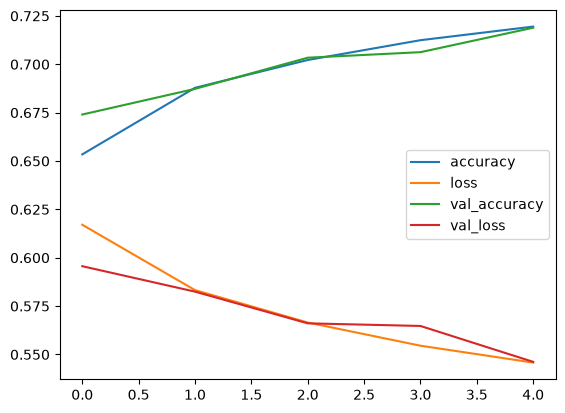

In [29]:
pd.DataFrame(history_2.history).plot()

This third model, characterised by a lower validation split, showed another small improvement in the accuracy with respect to the second one. Moreover, from the above plot it can be seen that this algorithm is not subject to overfitting, as it would lead to loss and validation loss curves, as well as accuracy and validation accuracy graphs, furthering apart one from the other. 

The next model has been built keeping the progressive improvements that had been obtained in the previous algorithms (increased number of layers and smaller validation split) and instead doubling the number of epochs from 5 to 10, hoping to reach a better training.  

In [30]:
from tensorflow.keras import models
from tensorflow.keras import Input, layers
higgs_DNN_3 = models.Sequential([
  Input(shape=(28,)),  
  layers.Dense(128, activation='relu'), 
  layers.Dense(128, activation='relu'),
  layers.Dense(128, activation='relu'),
  layers.Dense(128, activation='relu'),
  layers.Dense(128, activation='relu'),
  layers.Dense(1, activation='sigmoid')
])

In [31]:
higgs_DNN_3.compile(optimizer='adam', 
                   loss='binary_crossentropy', 
                   metrics=['accuracy']) 

In [32]:
%%time

history_3 = higgs_DNN_3.fit(X_train, y_train, epochs=10, batch_size=128, validation_split=0.3)

Epoch 1/10
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.6532 - loss: 0.6168 - val_accuracy: 0.6828 - val_loss: 0.5882
Epoch 2/10
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.6894 - loss: 0.5819 - val_accuracy: 0.6995 - val_loss: 0.5696
Epoch 3/10
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7032 - loss: 0.5655 - val_accuracy: 0.7056 - val_loss: 0.5605
Epoch 4/10
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.7125 - loss: 0.5541 - val_accuracy: 0.7088 - val_loss: 0.5569
Epoch 5/10
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.7193 - loss: 0.5452 - val_accuracy: 0.7203 - val_loss: 0.5445
Epoch 6/10
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.7257 - loss: 0.5370 - val_accuracy: 0.7186 - val_loss: 0.5500
Epoch 7/10
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.7295 - loss: 0.5311 - val_accuracy: 0.7254 - val_loss: 0.5403
Epoch 8/10
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.7343 - loss: 0.52

In [33]:
test_loss, test_acc = higgs_DNN_3.evaluate(X_test, y_test)
print('test_acc:', test_acc)

3125/3125 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.7239 - loss: 0.5405
test_acc: 0.7239000201225281


<Axes: >

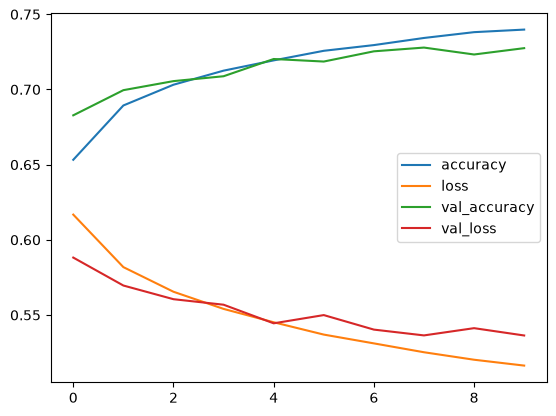

In [34]:
pd.DataFrame(history_3.history).plot()

The above results show that increasing the number of epochs did indeed lead to an increase in the accuracy, although the plot could indicate some signs of overfitting of the model. 

To test the hypothesis that the number of epochs could be the cause of the overfitting and to also search for a model with a better accuracy, the next algorithm was developed doubling again the number of epochs (from 10 to 20). 

In [35]:
from tensorflow.keras import models
from tensorflow.keras import Input, layers
higgs_DNN_4 = models.Sequential([
  Input(shape=(28,)),  
  layers.Dense(128, activation='relu'), 
  layers.Dense(128, activation='relu'),
  layers.Dense(128, activation='relu'),
  layers.Dense(128, activation='relu'),
  layers.Dense(128, activation='relu'),
  layers.Dense(1, activation='sigmoid')
])

In [36]:
higgs_DNN_4.compile(optimizer='adam', 
                   loss='binary_crossentropy', 
                   metrics=['accuracy']) 

In [37]:
%%time

history_4 = higgs_DNN_4.fit(X_train, y_train, epochs=20, batch_size=128, validation_split=0.3)

Epoch 1/20
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.6533 - loss: 0.6169 - val_accuracy: 0.6768 - val_loss: 0.5954
Epoch 2/20
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.6893 - loss: 0.5806 - val_accuracy: 0.6985 - val_loss: 0.5710
Epoch 3/20
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.7036 - loss: 0.5651 - val_accuracy: 0.7092 - val_loss: 0.5610
Epoch 4/20
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.7132 - loss: 0.5535 - val_accuracy: 0.7132 - val_loss: 0.5547
Epoch 5/20
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7206 - loss: 0.5444 - val_accuracy: 0.7165 - val_loss: 0.5498
Epoch 6/20
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.7252 - loss: 0.5369 - val_accuracy: 0.7187 - val_loss: 0.5491
Epoch 7/20
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.7305 - loss: 0.5307 - val_accuracy: 0.7243 - val_loss: 0.5377
Epoch 8/20
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.7340 - loss: 0.52

In [38]:
test_loss, test_acc = higgs_DNN_4.evaluate(X_test, y_test)
print('test_acc:', test_acc)

3125/3125 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.7335 - loss: 0.5286
test_acc: 0.7335100173950195


<Axes: >

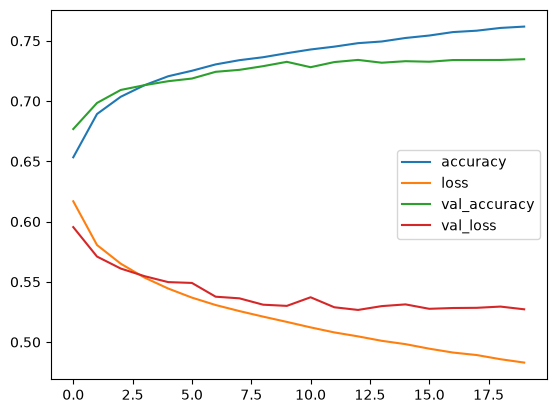

In [39]:
pd.DataFrame(history_4.history).plot()

The above plot seems to confirm the hypothesis: the number of epochs plays a role in the magnitude of the overfitting of the model. 

Another algorithm has been designed with the goal of finding a more accurate model. In this case the number of layers was increased again (passing from six to nine) and, instead, the epochs number has been set again to ten to avoid the overfitting effects seen previously. 

In [40]:
from tensorflow.keras import models
from tensorflow.keras import Input, layers
higgs_DNN_5 = models.Sequential([
  Input(shape=(28,)),  
  layers.Dense(128, activation='relu'), 
  layers.Dense(128, activation='relu'),
  layers.Dense(128, activation='relu'),
  layers.Dense(128, activation='relu'),
  layers.Dense(128, activation='relu'),
  layers.Dense(128, activation='relu'), 
  layers.Dense(128, activation='relu'),
  layers.Dense(128, activation='relu'),
  layers.Dense(1, activation='sigmoid')
])

In [41]:
higgs_DNN_5.compile(optimizer='adam', 
                   loss='binary_crossentropy', 
                   metrics=['accuracy'])

In [42]:
%%time

history_5 = higgs_DNN_5.fit(X_train, y_train, epochs=10, batch_size=128, validation_split=0.3)

Epoch 1/10
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - accuracy: 0.6510 - loss: 0.6183 - val_accuracy: 0.6848 - val_loss: 0.5922
Epoch 2/10
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - accuracy: 0.6876 - loss: 0.5831 - val_accuracy: 0.6986 - val_loss: 0.5715
Epoch 3/10
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.7025 - loss: 0.5681 - val_accuracy: 0.7057 - val_loss: 0.5664
Epoch 4/10
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.7124 - loss: 0.5561 - val_accuracy: 0.7136 - val_loss: 0.5551
Epoch 5/10
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.7186 - loss: 0.5469 - val_accuracy: 0.7175 - val_loss: 0.5483
Epoch 6/10
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.7250 - loss: 0.5405 - val_accuracy: 0.7222 - val_loss: 0.5434
Epoch 7/10
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.7292 - loss: 0.5339 - val_accuracy: 0.7199 - val_loss: 0.5470
Epoch 8/10
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.7324 - loss: 0

In [43]:
test_loss, test_acc = higgs_DNN_5.evaluate(X_test, y_test)
print('test_acc:', test_acc)

3125/3125 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.7262 - loss: 0.5392
test_acc: 0.7261800169944763


<Axes: >

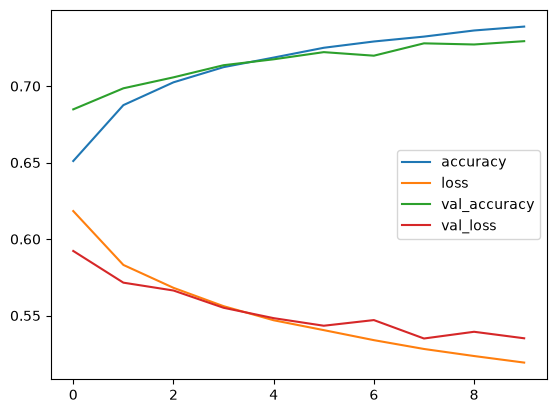

In [44]:
pd.DataFrame(history_5.history).plot()

This model shows a very scarce improvement in the test dataset accuracy with respect to the fourth algorithm, in this way not justifying the cost of increasing the number of layers. Moreover, signs of overfitting can be seen in the plot. 

The last two models have been developed using the same parameters of the fourth algorithm (higgs_DNN_3) and varying two important features that have been so far left untouched: the batch size in higgs_DNN_6 and the number of neurons in higgs_DNN_7. 

In [45]:
from tensorflow.keras import models
from tensorflow.keras import Input, layers
higgs_DNN_6 = models.Sequential([
  Input(shape=(28,)),  
  layers.Dense(128, activation='relu'), 
  layers.Dense(128, activation='relu'),
  layers.Dense(128, activation='relu'),
  layers.Dense(128, activation='relu'),
  layers.Dense(128, activation='relu'),
  layers.Dense(1, activation='sigmoid')
])

In [46]:
higgs_DNN_6.compile(optimizer='adam', 
                   loss='binary_crossentropy', 
                   metrics=['accuracy']) 

In [47]:
%%time

history_6 = higgs_DNN_6.fit(X_train, y_train, epochs=10, batch_size=1024, validation_split=0.3)

Epoch 1/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.6305 - loss: 0.6349 - val_accuracy: 0.6601 - val_loss: 0.6143
Epoch 2/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.6778 - loss: 0.5951 - val_accuracy: 0.6829 - val_loss: 0.5893
Epoch 3/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.6921 - loss: 0.5789 - val_accuracy: 0.6893 - val_loss: 0.5813
Epoch 4/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.6997 - loss: 0.5695 - val_accuracy: 0.7031 - val_loss: 0.5654
Epoch 5/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.7070 - loss: 0.5606 - val_accuracy: 0.7084 - val_loss: 0.5596
Epoch 6/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.7125 - loss: 0.5539 - val_accuracy: 0.7063 - val_loss: 0.5632
Epoch 7/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.7180 - loss: 0.5474 - val_accuracy: 0.7107 - val_loss: 0.5564
Epoch 8/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.7233 - loss: 0.5413 - val_accur

In [48]:
test_loss, test_acc = higgs_DNN_6.evaluate(X_test, y_test)
print('test_acc:', test_acc)

3125/3125 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.7170 - loss: 0.5487
test_acc: 0.7169700264930725


<Axes: >

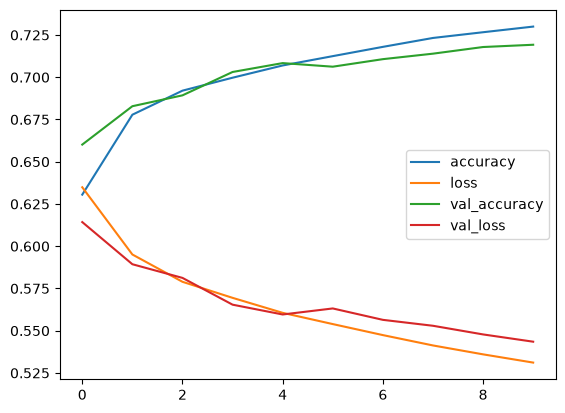

In [49]:
pd.DataFrame(history_6.history).plot()

Increasing the batch size has led to a decrease in the accuracy and also to the appearance of overfitting signs, so actually worsening the original higgs_DNN_3 model. 

In [50]:
from tensorflow.keras import models
from tensorflow.keras import Input, layers
higgs_DNN_7 = models.Sequential([
  Input(shape=(28,)),  
  layers.Dense(300, activation='relu'), 
  layers.Dense(300, activation='relu'),
  layers.Dense(1, activation='sigmoid') 
])

In [51]:
higgs_DNN_7.compile(optimizer='adam', 
                   loss='binary_crossentropy', 
                   metrics=['accuracy']) 

In [52]:
%%time

history_7 = higgs_DNN_7.fit(X_train, y_train, epochs=10, batch_size=128, validation_split=0.3)

Epoch 1/10
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - accuracy: 0.6548 - loss: 0.6166 - val_accuracy: 0.6800 - val_loss: 0.5969
Epoch 2/10
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.6894 - loss: 0.5819 - val_accuracy: 0.6996 - val_loss: 0.5722
Epoch 3/10
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.7033 - loss: 0.5666 - val_accuracy: 0.7052 - val_loss: 0.5650
Epoch 4/10
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.7127 - loss: 0.5554 - val_accuracy: 0.7109 - val_loss: 0.5630
Epoch 5/10
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.7193 - loss: 0.5469 - val_accuracy: 0.7183 - val_loss: 0.5479
Epoch 6/10
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 17s 5ms/step - accuracy: 0.7255 - loss: 0.5393 - val_accuracy: 0.7234 - val_loss: 0.5434
Epoch 7/10
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.7299 - loss: 0.5327 - val_accuracy: 0.7243 - val_loss: 0.5412
Epoch 8/10
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.7347 - loss: 0

In [53]:
test_loss, test_acc = higgs_DNN_7.evaluate(X_test, y_test)
print('test_acc:', test_acc)

3125/3125 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.7248 - loss: 0.5398
test_acc: 0.724810004234314


<Axes: >

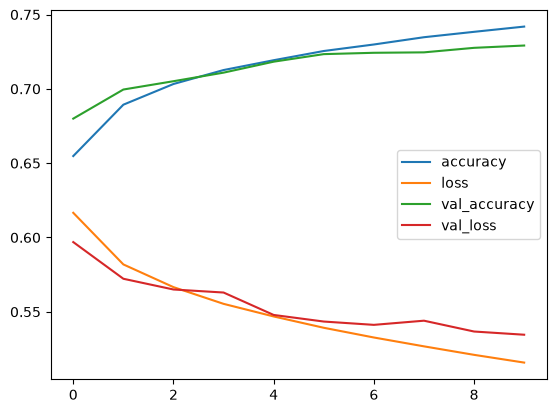

In [54]:
pd.DataFrame(history_7.history).plot()

The neurons number seems to play an important role in the accuracy value: increasing it from 128 to 1024 actually increased the training, validation and test accuracies. However, in the above plot some indications of potential overfitting can be seen. 

As it has been done for the Boosted Decision Tree models, also in this case ROC curves and AUC values have been used to identify the best-performing model among the eight considered so far. The results of this analysis are presented and discussed below. 

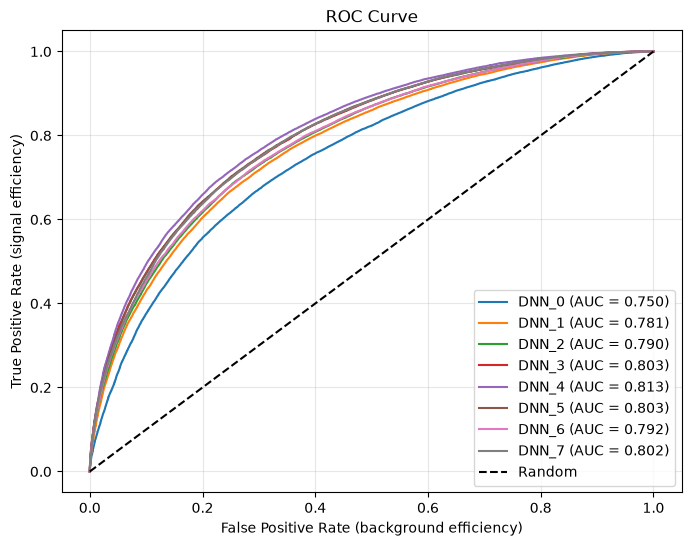

In [55]:
from sklearn.metrics import roc_curve, auc

models = [
    higgs_DNN_0,
    higgs_DNN_1,
    higgs_DNN_2,
    higgs_DNN_3,
    higgs_DNN_4,
    higgs_DNN_5,
    higgs_DNN_6,
    higgs_DNN_7
]

plt.figure(figsize=(8, 6))

for i, model in enumerate(models):
    y_scores_i = model.predict(X_test, verbose=0)
    fpr_i, tpr_i, thresholds_i = roc_curve(y_test, y_scores_i)
    auc_value_i = auc(fpr_i, tpr_i)
    plt.plot(
        fpr_i, 
        tpr_i, 
        label=f'DNN_{i} (AUC = {auc_value_i:.3f})'
    )
    
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate (background efficiency)')
plt.ylabel('True Positive Rate (signal efficiency)')
plt.title('ROC Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


Looking at the AUC values, it is strikingly evident the abrupt increase in efficiency passing from the first basic model (higgs_DNN_0) to the second one (higgs_DNN_1), where the only difference was related to the increase in the number of layers. Considering just the above plot, the best-performing model could be the fifth one (higgs_DNN_4), characterised by having the largest number of epochs with respect to the other algorithms (20). However, that same model showed also dramatic signs of overfitting, therefore showing that the choice of the model to use should take into consideration different parameters and not just one. For this reason, the algorithm which seems to have not only a number of layers and neurons which justify the obtained values of accuracy and AUC, but also no signs of overfitting, is the third one (higgs_DNN_2), characterised by six layers, each with 128 neurons, and "epochs" = 5, "batch_size" = 128, "validation_split" = 0.3. 

For better visualisation, the ROC curves for the five models with the highest AUC values (higgs_DNN_2, higgs_DNN_3, higgs_DNN_4, higgs_DNN_5, higgs_DNN_7) are visible below.

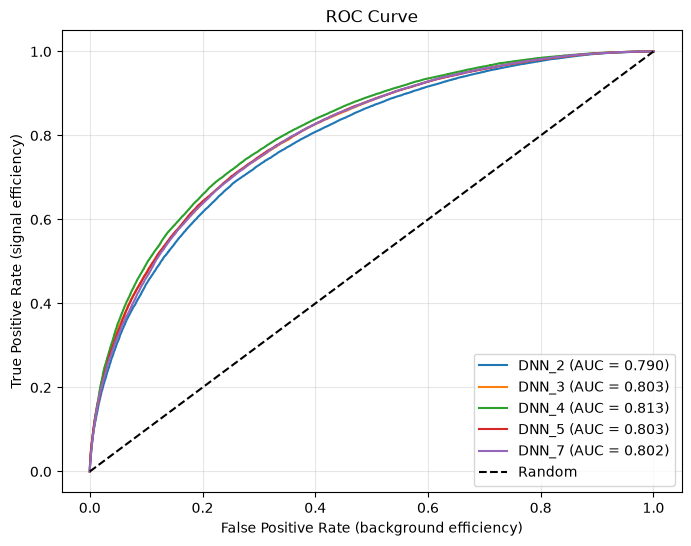

In [56]:
from sklearn.metrics import roc_curve, auc

models = [
    (2, higgs_DNN_2),
    (3, higgs_DNN_3),
    (4, higgs_DNN_4),
    (5, higgs_DNN_5),
    (7, higgs_DNN_7)
]

plt.figure(figsize=(8, 6))

for dnn_number, model in models:
    y_scores = model.predict(X_test, verbose=0)
    
    fpr, tpr, thresholds = roc_curve(y_test, y_scores)
    auc_value = auc(fpr, tpr)
    
    plt.plot(
        fpr,
        tpr,
        label=f'DNN_{dnn_number} (AUC = {auc_value:.3f})'
    )

plt.plot([0, 1], [0, 1], 'k--', label='Random')

plt.xlabel('False Positive Rate (background efficiency)')
plt.ylabel('True Positive Rate (signal efficiency)')
plt.title('ROC Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Recalling the analysis of the feature importance performed during the training of the models using Boosted Decision Trees, which showed that high-level features have a significantly greater impact on the training than low-level features, the same approach is applied here to Deep Neural Networks. In this case as well, the analysis is performed using the algorithm that achieved the best performance in the previous study, namely higgs_DNN_2. 

In [57]:
y_l = df.iloc[:, 0].values         
X_l = df.iloc[:, 1:22].values 

In [58]:
from sklearn.model_selection import train_test_split

X_l_train_full, X_l_test, y_l_train_full, y_l_test = train_test_split(X_l, y_l, test_size=0.2, random_state=42) 

X_l_train, X_l_val, y_l_train, y_l_val = train_test_split(X_l_train_full, y_l_train_full, test_size=0.10, random_state=42) 

In [62]:
from tensorflow.keras import models
from tensorflow.keras import Input, layers
higgs_DNN_2_l = models.Sequential([
  Input(shape=(21,)),  
  layers.Dense(128, activation='relu'), 
  layers.Dense(128, activation='relu'),
  layers.Dense(128, activation='relu'),
  layers.Dense(128, activation='relu'),
  layers.Dense(128, activation='relu'),
  layers.Dense(1, activation='sigmoid')
])

In [63]:
higgs_DNN_2_l.compile(optimizer='adam', 
                   loss='binary_crossentropy', 
                   metrics=['accuracy']) 

In [64]:
%%time

history_2_l = higgs_DNN_2_l.fit(X_l_train, y_l_train, epochs=5, batch_size=128, validation_split=0.3)

Epoch 1/5
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.6037 - loss: 0.6558 - val_accuracy: 0.6302 - val_loss: 0.6378
Epoch 2/5
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.6411 - loss: 0.6277 - val_accuracy: 0.6504 - val_loss: 0.6214
Epoch 3/5
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.6596 - loss: 0.6127 - val_accuracy: 0.6606 - val_loss: 0.6117
Epoch 4/5
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.6711 - loss: 0.6022 - val_accuracy: 0.6661 - val_loss: 0.6073
Epoch 5/5
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.6785 - loss: 0.5944 - val_accuracy: 0.6716 - val_loss: 0.6005
CPU times: user 1min 11s, sys: 12.9 s, total: 1min 23s
Wall time: 51.9 s


In [65]:
test_loss, test_acc = higgs_DNN_2_l.evaluate(X_l_test, y_l_test)
print('test_acc:', test_acc)

3125/3125 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.6712 - loss: 0.6020
test_acc: 0.671209990978241


In [66]:
y_h = df.iloc[:, 0].values         
X_h = df.iloc[:, 22:].values 

In [67]:
from sklearn.model_selection import train_test_split

X_h_train_full, X_h_test, y_h_train_full, y_h_test = train_test_split(X_h, y_h, test_size=0.2, random_state=42) 

X_h_train, X_h_val, y_h_train, y_h_val = train_test_split(X_h_train_full, y_h_train_full, test_size=0.10, random_state=42)

In [68]:
from tensorflow.keras import models
from tensorflow.keras import Input, layers
higgs_DNN_2_h = models.Sequential([
  Input(shape=(7,)),  
  layers.Dense(128, activation='relu'), 
  layers.Dense(128, activation='relu'),
  layers.Dense(128, activation='relu'),
  layers.Dense(128, activation='relu'),
  layers.Dense(128, activation='relu'),
  layers.Dense(1, activation='sigmoid')
])

In [69]:
higgs_DNN_2_h.compile(optimizer='adam', 
                   loss='binary_crossentropy', 
                   metrics=['accuracy']) 

In [70]:
%%time

history_2_h = higgs_DNN_2_h.fit(X_h_train, y_h_train, epochs=5, batch_size=128, validation_split=0.3)

Epoch 1/5
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.6752 - loss: 0.5940 - val_accuracy: 0.6952 - val_loss: 0.5701
Epoch 2/5
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.6932 - loss: 0.5708 - val_accuracy: 0.6891 - val_loss: 0.5767
Epoch 3/5
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.6978 - loss: 0.5660 - val_accuracy: 0.6983 - val_loss: 0.5671
Epoch 4/5
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.6994 - loss: 0.5627 - val_accuracy: 0.6973 - val_loss: 0.5649
Epoch 5/5
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.7013 - loss: 0.5605 - val_accuracy: 0.7032 - val_loss: 0.5584
CPU times: user 1min 4s, sys: 12.4 s, total: 1min 17s
Wall time: 44.7 s


In [71]:
test_loss, test_acc = higgs_DNN_2_h.evaluate(X_h_test, y_h_test)
print('test_acc:', test_acc)

3125/3125 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.7025 - loss: 0.5595
test_acc: 0.7025399804115295


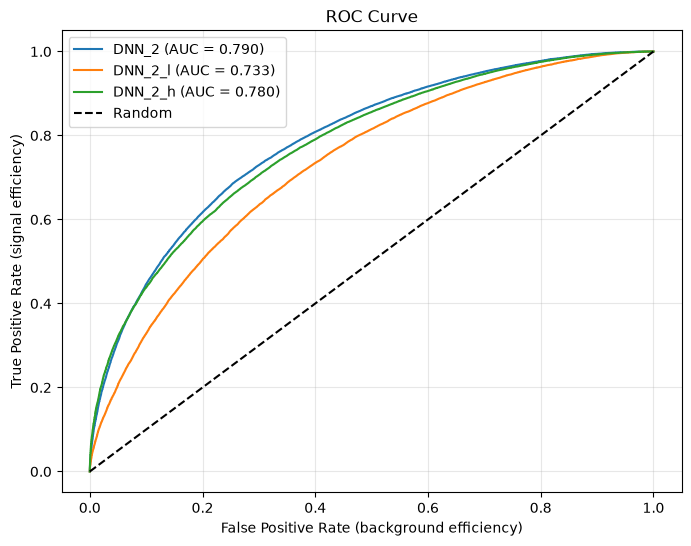

In [73]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8, 6))

y_scores = higgs_DNN_2.predict(X_test, verbose=0)
fpr, tpr, thresholds = roc_curve(y_test, y_scores)
auc_value = auc(fpr, tpr)
plt.plot(
    fpr,
    tpr,
    label=f'DNN_2 (AUC = {auc_value:.3f})'
)

y_scores = higgs_DNN_2_l.predict(X_l_test, verbose=0) 
fpr, tpr, thresholds = roc_curve(y_l_test, y_scores)
auc_value = auc(fpr, tpr)
plt.plot(
    fpr,
    tpr,
    label=f'DNN_2_l (AUC = {auc_value:.3f})'
)

y_scores = higgs_DNN_2_h.predict(X_h_test, verbose=0) 
fpr, tpr, thresholds = roc_curve(y_h_test, y_scores)
auc_value = auc(fpr, tpr)
plt.plot(
    fpr,
    tpr,
    label=f'DNN_2_h (AUC = {auc_value:.3f})'
)

plt.plot([0, 1], [0, 1], 'k--', label='Random')

plt.xlabel('False Positive Rate (background efficiency)')
plt.ylabel('True Positive Rate (signal efficiency)')
plt.title('ROC Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

The ROC curves and corresponding AUC values show a behaviour consistent with that observed for Boosted Decision Trees: high-level features play a significant role in the training and performance of the models. In the case of Deep Neural Networks, their contribution appears to be even more pronounced, as indicated by the small difference in AUC between the model trained exclusively on high-level features and the model trained using the complete feature set.